# 3F - Ondas de Kelvin por SLA/SSH e vento

**Pergunta especifica.** A dinamica equatorial mostra propagacao oeste-leste compativel com ondas Kelvin de downwelling nos eventos fortes/muito fortes e na janela 2025/26?

**Objetivo.** Documentar a leitura Hovmoller de SLA/SSH e a coerencia temporal com anomalias de estresse zonal do vento na caixa Nino 3.4.

**Justificativa.** O pico do El Nino depende da redistribuicao dinamica de calor no Pacifico equatorial. SLA/SSH positivo e propagacao oeste-leste indicam aprofundamento/expansao da coluna d'agua, coerente com ondas Kelvin de downwelling quando acompanhado por anomalias de oeste em `tau_x_anom`.

**Metodologia.** Hovmoller de SLA local (SSH menos media da janela por longitude) em 1997/98, 2015/16, 2023/24 e 2025/26; resumo numerico por janela; serie conjunta de SLA medio na caixa Nino 3.4 e `tau_x_anom_nino34_pa`.

**Saidas.** `phase3F_kelvin_eventos_resumo.csv`, `3F1_hovmoller_sla_kelvin.png`, `3F2_taux_sla_eventos.png`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u

w = pd.read_csv(u.FEAT/'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ssh = u.load_ssh_events()
atmo = u.load_atmo()
tau = u.daily_doy_anomaly(u.zonal_wind_stress_proxy(atmo['atm_10m_u_component_of_wind'])).rename('tau_x_anom_nino34_pa')

windows = [
    ('1997-01-01','1998-06-30','1997/98'),
    ('2015-01-01','2016-06-30','2015/16'),
    ('2023-01-01','2024-06-30','2023/24'),
    ('2025-07-01',None,'2025/26 atual'),
]
rows = []
for t0, t1, label in windows:
    seg = ssh.loc[t0:t1] if t1 else ssh.loc[t0:]
    seg = seg.dropna(how='all')
    if seg.empty:
        rows.append({'janela': label, 'inicio': t0, 'fim': t1 or '', 'status': 'sem dados SSH'})
        continue
    lon = seg.columns.astype(float)
    sla = seg - seg.mean(axis=0)
    band = (lon >= 190) & (lon <= 240)
    n34 = sla.loc[:, band].mean(axis=1)
    tau_seg = tau.loc[seg.index.min():seg.index.max()]
    loc = np.nanargmax(sla.values)
    rr, cc = np.unravel_index(loc, sla.values.shape)
    rows.append({
        'janela': label,
        'inicio': str(seg.index.min().date()),
        'fim': str(seg.index.max().date()),
        'max_sla_m': round(float(np.nanmax(sla.values)), 3),
        'min_sla_m': round(float(np.nanmin(sla.values)), 3),
        'data_max_sla': str(seg.index[rr].date()),
        'longitude_max_sla': u.lon_label(float(lon[cc])),
        'sla_medio_nino34_m': round(float(n34.mean()), 3),
        'tau_x_anom_media_pa': round(float(tau_seg.mean()), 5) if not tau_seg.empty else np.nan,
        'frac_tau_x_oeste': round(float((tau_seg > 0).mean()), 3) if not tau_seg.empty else np.nan,
        'leitura': 'SLA positivo e tau_x medio positivo favorecem leitura de downwelling/Kelvin' if (not tau_seg.empty and float(n34.mean()) > 0 and float(tau_seg.mean()) > 0) else 'leitura diagnostica; verificar inclinacao no Hovmoller',
    })
resumo = pd.DataFrame(rows)
u.save_table(resumo, 'phase3F_kelvin_eventos_resumo.csv', index=False)
print(resumo.to_string(index=False))

[tabela] data\processed\parquet\statistics\phase3F_kelvin_eventos_resumo.csv
       janela     inicio        fim  max_sla_m  min_sla_m data_max_sla longitude_max_sla  sla_medio_nino34_m  tau_x_anom_media_pa  frac_tau_x_oeste                                                                     leitura
      1997/98 1997-01-01 1998-06-30      0.326     -0.320   1997-11-29               80W                 0.0              0.02197             0.832 SLA positivo e tau_x medio positivo favorecem leitura de downwelling/Kelvin
      2015/16 2015-01-01 2016-06-30      0.233     -0.239   2015-12-02               80W                -0.0              0.01395             0.764                      leitura diagnostica; verificar inclinacao no Hovmoller
      2023/24 2023-01-01 2024-06-30      0.241     -0.186   2023-12-08              129W                 0.0             -0.00159             0.470                      leitura diagnostica; verificar inclinacao no Hovmoller
2025/26 atual 2025-07-01 20

[figura] data\processed\figures\fase3\3F1_hovmoller_sla_kelvin.png


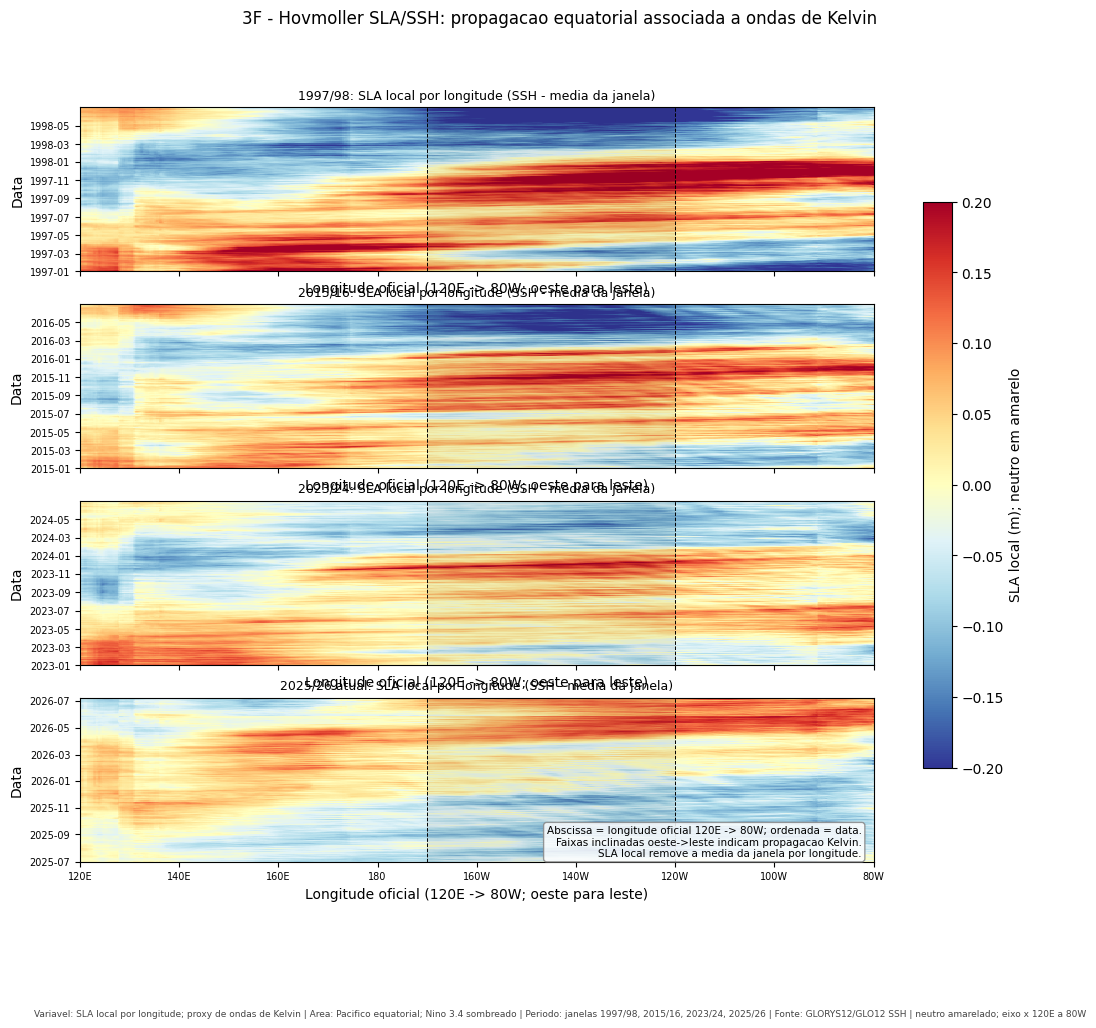

In [2]:
fig, axes = plt.subplots(len(windows), 1, figsize=(12.8, 9.8), sharex=True)
last_pc = None
for ax, (t0, t1, title) in zip(axes, windows):
    seg = ssh.loc[t0:t1] if t1 else ssh.loc[t0:]
    seg = seg.dropna(how='all')
    if seg.empty:
        ax.text(.5, .5, 'sem dados SSH nesta janela', transform=ax.transAxes, ha='center')
        continue
    lon = seg.columns.values.astype(float)
    sla = seg - seg.mean(axis=0)
    last_pc = ax.pcolormesh(lon, seg.index, sla.values, cmap='RdYlBu_r', vmin=-0.20, vmax=0.20, shading='auto')
    u.add_nino34_lon_band(ax, label=False)
    u.format_lon_axis(ax)
    ax.set_ylabel('Data')
    ax.set_title(f'{title}: SLA local por longitude (SSH - media da janela)', fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle('3F - Hovmoller SLA/SSH: propagacao equatorial associada a ondas de Kelvin')
if last_pc is not None:
    fig.colorbar(last_pc, ax=axes, label='SLA local (m); neutro em amarelo', shrink=.75)
u.add_note(axes[-1], 'Abscissa = longitude oficial 120E -> 80W; ordenada = data.\nFaixas inclinadas oeste->leste indicam propagacao Kelvin.\nSLA local remove a media da janela por longitude.', loc='lower right')
u.stamp_caption(fig, variavel='SLA local por longitude; proxy de ondas de Kelvin', area='Pacifico equatorial; Nino 3.4 sombreado', periodo='janelas 1997/98, 2015/16, 2023/24, 2025/26', fonte='GLORYS12/GLO12 SSH', extra='neutro amarelado; eixo x 120E a 80W')
u.save_fig(fig, '3F1_hovmoller_sla_kelvin.png')
plt.show()

[figura] data\processed\figures\fase3\3F2_taux_sla_eventos.png


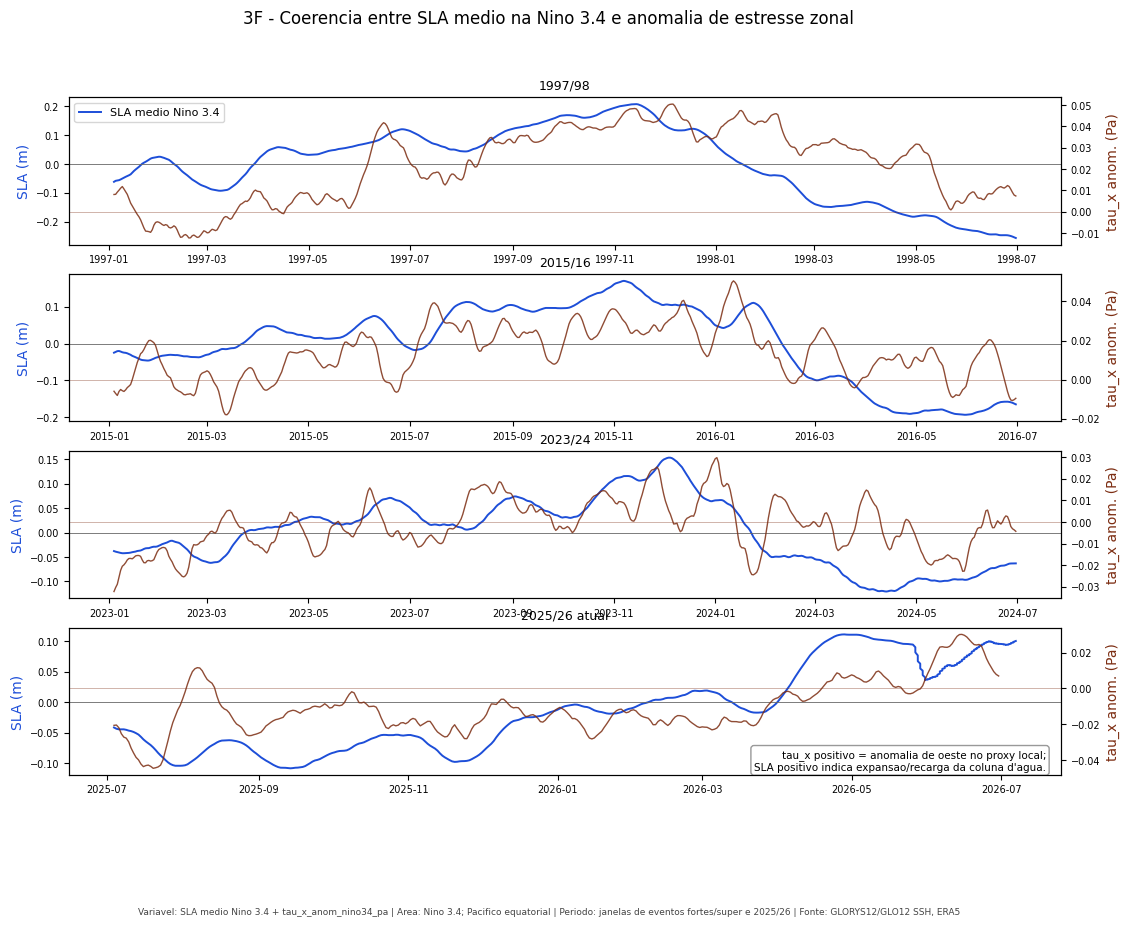

In [3]:
fig, axes = plt.subplots(len(windows), 1, figsize=(12.8, 8.8), sharex=False)
for ax, (t0, t1, title) in zip(axes, windows):
    seg = ssh.loc[t0:t1] if t1 else ssh.loc[t0:]
    seg = seg.dropna(how='all')
    if seg.empty:
        ax.text(.5, .5, 'sem dados', transform=ax.transAxes, ha='center')
        continue
    lon = seg.columns.astype(float)
    sla = seg - seg.mean(axis=0)
    n34 = sla.loc[:, (lon >= 190) & (lon <= 240)].mean(axis=1).rolling(14, min_periods=4).mean()
    taux = tau.loc[seg.index.min():seg.index.max()].rolling(14, min_periods=4).mean()
    ax.plot(n34.index, n34, color='#1d4ed8', lw=1.4, label='SLA medio Nino 3.4')
    ax.axhline(0, color='0.4', lw=.6)
    ax.set_ylabel('SLA (m)', color='#1d4ed8')
    ax2 = ax.twinx()
    ax2.plot(taux.index, taux, color='#7c2d12', lw=1.0, alpha=.85, label='tau_x anom.')
    ax2.axhline(0, color='#7c2d12', lw=.5, alpha=.5)
    ax2.set_ylabel('tau_x anom. (Pa)', color='#7c2d12')
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7)
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('3F - Coerencia entre SLA medio na Nino 3.4 e anomalia de estresse zonal')
u.add_note(axes[-1], 'tau_x positivo = anomalia de oeste no proxy local;\nSLA positivo indica expansao/recarga da coluna d\'agua.', loc='lower right')
u.stamp_caption(fig, variavel='SLA medio Nino 3.4 + tau_x_anom_nino34_pa', area='Nino 3.4; Pacifico equatorial', periodo='janelas de eventos fortes/super e 2025/26', fonte='GLORYS12/GLO12 SSH, ERA5')
u.save_fig(fig, '3F2_taux_sla_eventos.png')
plt.show()

**Leitura do 3F.** A etapa 3F fica restrita a dinamica equatorial: SLA/SSH mostra a resposta da coluna d'agua e `tau_x_anom_nino34_pa` mostra o acoplamento vento-superficie. Faixas inclinadas de oeste para leste no Hovmoller sao compat?veis com propagacao Kelvin; sinais positivos de SLA no centro-leste indicam aprofundamento/expansao da coluna d'agua, fisicamente favoravel ao aquecimento superficial posterior. A leitura e diagnostica e qualitativa, nao um detector automatico formal de ondas.